In [3]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Suppress overflow warnings
np.seterr(over='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

Normalization constant:  0.9388545625223099 Error:  5.136144044557452e-09


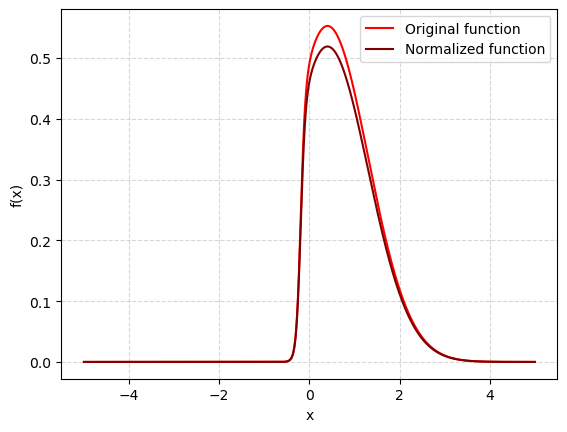

In [4]:
# defining the function to be normalized
def f(x):
    exp_term = np.exp(-x**2 / 2)
    sigmoid_term = 1.0 / (1.0 + np.exp(-x))
    return exp_term * sigmoid_term / (1 + np.exp(-20*x - 4))


x = np.linspace(-5,5,10000)
plt.figure()
plt.plot(x, f(x),color='red', label='Original function')

# evaluating the normalization constant
Z , error = quad(f, -np.inf, np.inf)

print("Normalization constant: ", Z , "Error: ", error)

def Normalized_f(x, Z):
    return Z * f(x)

plt.plot(x, Normalized_f(x, Z),color = "maroon", label='Normalized function')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, linestyle = "dashed", alpha = 0.5)
plt.legend()

In [5]:
import numpy as np
from scipy.optimize import minimize_scalar

# Define the functions f(x), f'(x), and -d^2(log(f))/dx^2
def f(x):
    return np.exp(-x**2 / 2) / (1 + np.exp(-20*x - 4))

def df(x):
    return (-x * np.exp(-x**2 / 2) * f(x) +
            20 * np.exp(-x**2 / 2) * f(x) * (1 - f(x)))

def d2f(x):
    return 20 * np.exp(-x**2 / 2) * (1 - f(x)) * f(x) - x * np.exp(-x**2 / 2) * f(x)

# Step 1: Find mu1 by solving f'(mu1) = 0
result_mu1 = minimize_scalar(df)
mu1 = result_mu1.x

# Step 2: Find 1/sigma1^2 by evaluating -d^2(log(f))/dx^2 at x = mu1
sigma1_inv_squared = -1 / d2f(mu1)

# Display results
print("mu1:", mu1)
print("sigma1:", np.sqrt(1 / sigma1_inv_squared))


mu1: -44.36068048515748
sigma1: -0.0


/tmp/ipykernel_779131/545144442.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  sigma1_inv_squared = -1 / d2f(mu1)


In [2]:
import numpy as np
from scipy.optimize import line_search

# Define the objective function
def objective_function(x):
    return np.exp(-x**2 / 2) / (1 + np.exp(-20*x - 4))

# Define the gradient of the objective function
def gradient(x):
    return  (-x * np.exp(-x**2 / 2) * objective_function(x) +
            20 * np.exp(-x**2 / 2) * objective_function(x) * (1 - objective_function(x)))

# Initial guess
x0 = np.array([1.0])

# Initialize p0 and r0
p = -gradient(x0)
r = p.copy()

# Define convergence tolerance
tolerance = 1e-6

alpha0 = 0.5  # Initial step size
rho = 0.5  # Parameter for the backtracking condition (0 < rho < 1)
gamma = 0.0001  # Parameter for the backtracking condition (0 < gamma < 1)

# Nonlinear conjugate gradient method
for k in range(100):  # You can adjust the number of iterations as needed
    # Line search to find step size alpha
    
    # alpha = line_search(objective_function, gradient, xk=x0, pk=p)[0] #inbuilt function 
    
    # Backtracking line search
    alpha = alpha0
    while objective_function(x0 + alpha * p) > objective_function(x0) + gamma * alpha * np.dot(gradient(x0), p):
        alpha = rho * alpha




    # Update x and calculate new gradient
    x1 = x0 + alpha * p
    r1 = -gradient(x1)

    # Calculate beta using Fletcher-Reeves formula
    beta = np.dot(r1, r1) / np.dot(r, r)

    # calculate beta using Polak Ribiere formula
    #beta = np.dot(r1, r1 - r)/ np.dot(r, r)

    # Update p using the conjugate direction update
    p = r1 + beta * p

    # Update x and r for the next iteration
    x0 = x1
    r = r1

    # Check convergence condition and break if satisfied
    if np.linalg.norm(r) < tolerance:
        break

print("Optimal solution:", x0)
print("Optimal value:", objective_function(x0))


Optimal solution: [-4.02578776]
Optimal value: [1.77963762e-37]


/tmp/ipykernel_779131/1656993696.py:5: RuntimeWarning: invalid value encountered in sqrt
  return np.exp(-0.5 * sigma_inv_squared * (x - mu)**2) / np.sqrt(2 * np.pi * sigma_inv_squared)


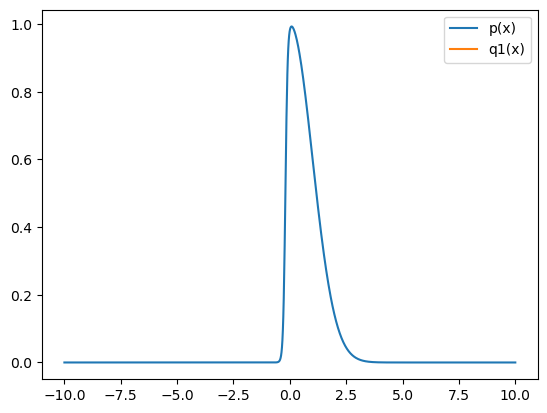

In [6]:
import matplotlib.pyplot as plt

# Step 3: Construct Laplace Approximation q1(x)
def q1(x, mu, sigma_inv_squared):
    return np.exp(-0.5 * sigma_inv_squared * (x - mu)**2) / np.sqrt(2 * np.pi * sigma_inv_squared)

# Generate x values for plotting
x_values = np.linspace(-10, 10, 1000)

# Step 4: Compare Plots
plt.plot(x_values, f(x_values), label='p(x)')
plt.plot(x_values, q1(x_values, mu1, sigma1_inv_squared), label='q1(x)')
plt.legend()
plt.show()
